<a href="https://colab.research.google.com/github/MandadiChandana/AI-health-analysis-and-disease-prediction/blob/main/Facial_Image_Analysis_for_Accurate_Diagnosis_of_Down_Syndrome_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

# Importing dependencies


In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 19.2 MB/s eta 0:00:00


In [ ]:

import os
import random
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import cv2
import visualkeras


from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, Conv2D, Flatten, GlobalAveragePooling2D, BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 15
BATCH_SIZE = 8

#Mounting the dataset

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.utils import shuffle

# Mount Google Drive
drive.mount('/content/drive')

# Function to create a list of image paths
def create_images_list(path):
    full_path = []
    images = os.listdir(path)
    for i in tqdm(images, desc='images'):
        full_path.append(os.path.join(path, i))
    return full_path

# Paths to datasets in Google Drive
train_healthy_path = '/content/drive/MyDrive/dataset/Down syndromedataset/train/healthy'
train_down_path = '/content/drive/MyDrive/dataset/Down syndromedataset/train/downsyndrome'
test_healthy_path = '/content/drive/MyDrive/dataset/Down syndromedataset/test/healthy'
test_down_path = '/content/drive/MyDrive/dataset/Down syndromedataset/test/downsyndrome'

# Create lists of image paths
train_healthy = create_images_list(train_healthy_path)
train_down = create_images_list(train_down_path)
test_healthy = create_images_list(test_healthy_path)
test_down = create_images_list(test_down_path)

# Print counts of training and testing images
print(f"Number of training images (healthy): {len(train_healthy)}")
print(f"Number of training images (down): {len(train_down)}")
print(f"Number of testing images (healthy): {len(test_healthy)}")
print(f"Number of testing images (down): {len(test_down)}")

# Lookup table for classes
disease_classes = {0: 'healthy', 1: 'down'}

# Create the main dataframe
data_df = pd.concat([
    pd.DataFrame({"img": np.array(train_healthy), "label": 0}),
    pd.DataFrame({"img": np.array(train_down), "label": 1})
], ignore_index=True)

# Shuffle the dataframe
data_df = shuffle(data_df).reset_index(drop=True)

# Display the first few rows of the dataframe
print(data_df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


images: 100%|██████████| 141/141 [00:00<00:00, 516053.11it/s]

Number of training images (healthy): 3103
Number of training images (down): 2941
Number of testing images (healthy): 149
Number of testing images (down): 141
                                                 img  label
0  /content/drive/MyDrive/dataset/Down syndromeda...      1
1  /content/drive/MyDrive/dataset/Down syndromeda...      0
2  /content/drive/MyDrive/dataset/Down syndromeda...      0
3  /content/drive/MyDrive/dataset/Down syndromeda...      1
4  /content/drive/MyDrive/dataset/Down syndromeda...      1


# Creating random 4 sample from a dataframe


In [ ]:


def create_img_label_sample(data, index):

    img = cv2.imread(data['img'][index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label = disease_classes[data_df['label'][index]]

    return img, label


def create_random_samples(data):

    idx1,idx2,idx3,idx4 =np.random.permutation(data.shape[0])[:4]

    fig, axs = plt.subplots(1,4, figsize = (12,5), dpi = 300)

    img1, name1 = create_img_label_sample(data, idx1)
    img2, name2 = create_img_label_sample(data, idx2)
    img3, name3 = create_img_label_sample(data, idx3)
    img4, name4 = create_img_label_sample(data, idx4)


    axs[0].imshow(img1)
    axs[0].set_title(name1)
    axs[0].axis('off')

    axs[1].imshow(img2)
    axs[1].set_title(name2)
    axs[1].axis('off')

    axs[2].imshow(img3)
    axs[2].set_title(name3)
    axs[2].axis('off')

    axs[3].imshow(img4)
    axs[3].set_title(name4)
    axs[3].axis('off')

    plt.show()

# Random samples


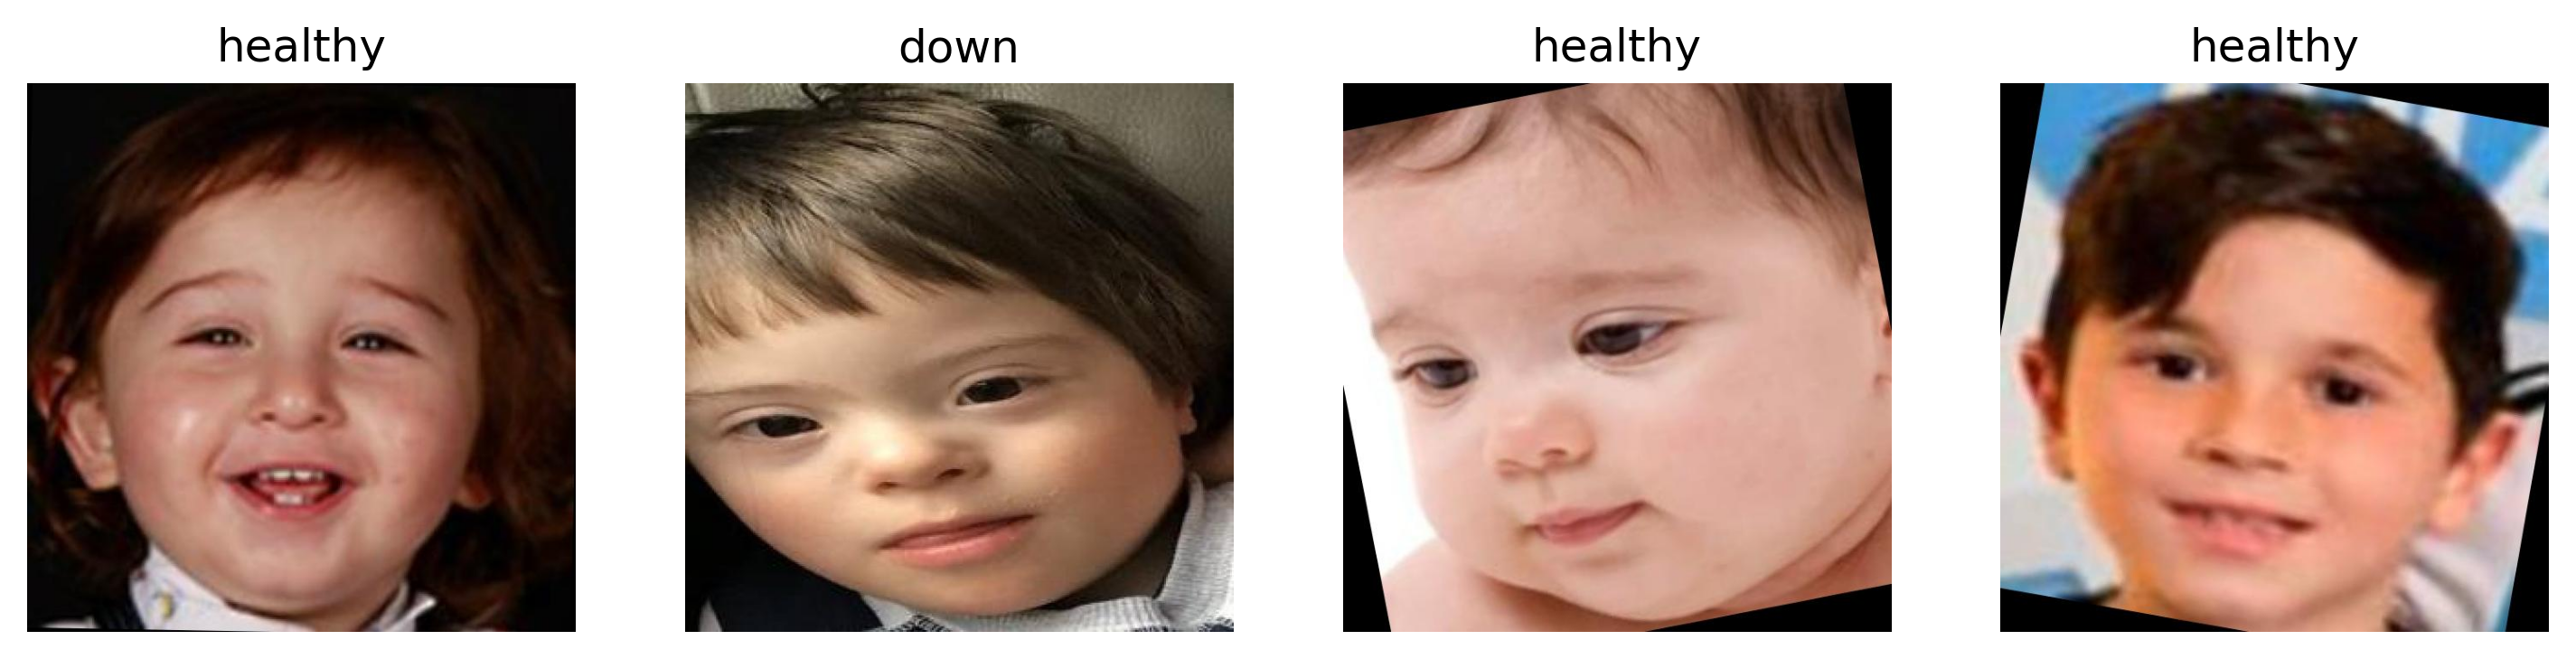

In [ ]:

create_random_samples(data_df)

# Class distribution in training and testing datasets


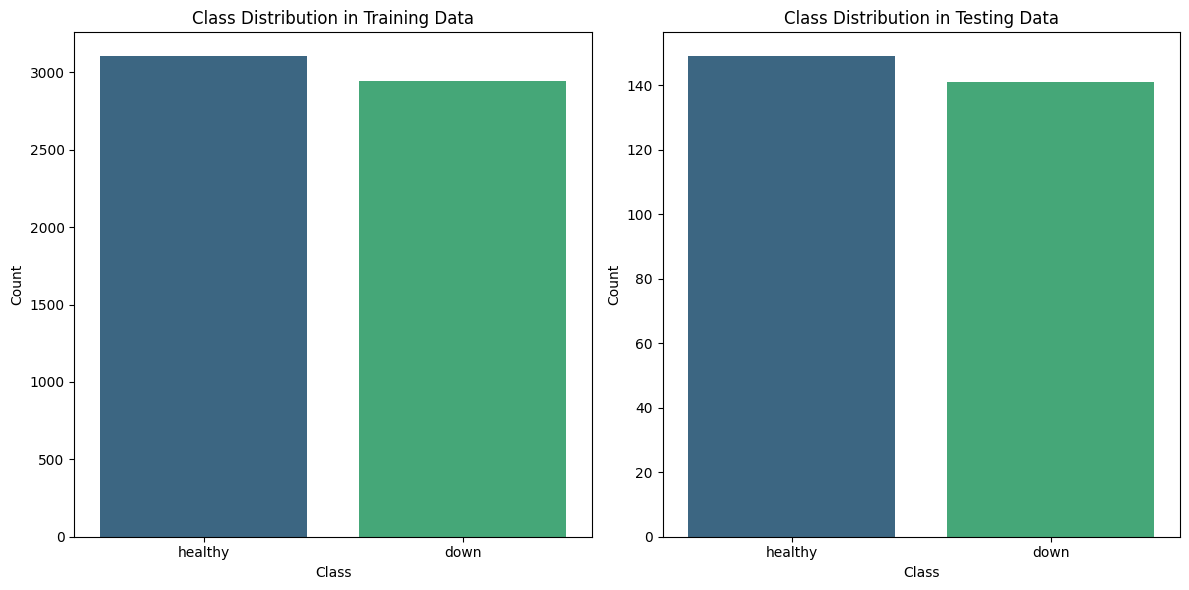

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine training and testing data for EDA
train_df = pd.concat([
    pd.DataFrame({"img": np.array(train_healthy), "label": 0}),
    pd.DataFrame({"img": np.array(train_down), "label": 1})
], ignore_index=True)

test_df = pd.concat([
    pd.DataFrame({"img": np.array(test_healthy), "label": 0}),
    pd.DataFrame({"img": np.array(test_down), "label": 1})
], ignore_index=True)

# Label mappings for classes
disease_classes = {0: 'healthy', 1: 'down'}

# Add readable class names for EDA
train_df['class'] = train_df['label'].map(disease_classes)
test_df['class'] = test_df['label'].map(disease_classes)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='class', palette='viridis')
plt.title("Class Distribution in Training Data")
plt.xlabel("Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(data=test_df, x='class', palette='viridis')
plt.title("Class Distribution in Testing Data")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_df['img'], data_df['label'], test_size = 0.15,  random_state = SEED)

print("train images: ", X_train.shape[0])
print("test images: ", X_test.shape[0])

train images:  5137
test images:  907


# Preprocessing

In [ ]:
import tensorflow as tf

def img_preprocessing(image, label):
    # Load and decode the image
    img = tf.io.read_file(image)
    img = tf.io.decode_jpeg(img, channels=3)

    # Resize the image
    img = tf.image.resize(img, size=(250, 250))

    # Normalize pixel values to [0, 1]
    img = img / 255.0

    # Data augmentation (only for training)
    img = tf.image.random_flip_left_right(img)  # Random horizontal flip
    img = tf.image.random_flip_up_down(img)    # Random vertical flip
    img = tf.image.random_brightness(img, max_delta=0.2)  # Random brightness adjustment
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)  # Random contrast adjustment
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)  # Random saturation adjustment

    # Ensure the pixel values are still in [0, 1]
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, label


#Train test splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_df['img'], data_df['label'], test_size = 0.15,  random_state = SEED)

print("train images: ", X_train.shape[0])
print("test images: ", X_test.shape[0])

train images:  5137
test images:  907


In [ ]:
# Creating dataset loaders

train_loader = tf.data.Dataset.from_tensor_slices(( X_train, y_train) )
train_dataset = (train_loader.map(img_preprocessing).batch(BATCH_SIZE).shuffle(X_train.shape[0]).prefetch(BATCH_SIZE))

test_loader = tf.data.Dataset.from_tensor_slices(( X_test, y_test) )
test_dataset = (test_loader.map(img_preprocessing).batch(BATCH_SIZE).prefetch(BATCH_SIZE))

#ResNet101

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 881s 287ms/step - accuracy: 0.5151 - loss: 0.8137 - val_accuracy: 0.5094 - val_loss: 0.6959
Epoch 2/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 118s 69ms/step - accuracy: 0.5233 - loss: 0.7622 - val_accuracy: 0.5954 - val_loss: 0.6808
Epoch 3/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 62s 68ms/step - accuracy: 0.5056 - loss: 0.7381 - val_accuracy: 0.5722 - val_loss: 0.6776
Epoch 4/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 78s 62ms/step - accuracy: 0.5066 - loss: 0.7147 - val_accuracy: 0.5932 - val_loss: 0.6739
Epoch 5/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 59s 62ms/step - accuracy: 0.5317 - loss: 0.7030 - val_accuracy: 0.6262 - val_loss: 0.6710
Epoch 6/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.5552 - loss: 0.6856 - val_accuracy: 0.6483 - val_loss: 0.6670
Epoch 7/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.5609 - loss: 0.6804 - val_accuracy: 0.6207 - val_loss: 0.6655
Epoch 8/15
643/643 ━━━━━━━━━━━━━━━

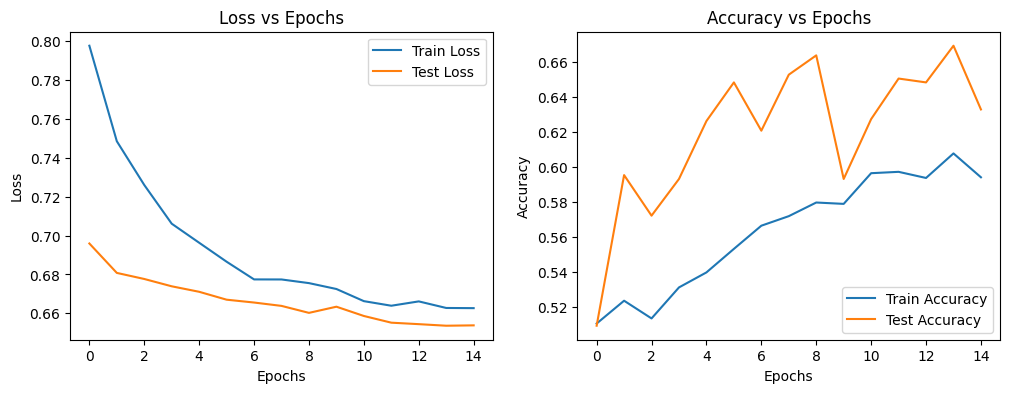

114/114 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step
              precision    recall  f1-score   support

           0       0.59      0.88      0.71       462
           1       0.75      0.37      0.50       445

    accuracy                           0.63       907
   macro avg       0.67      0.63      0.60       907
weighted avg       0.67      0.63      0.61       907



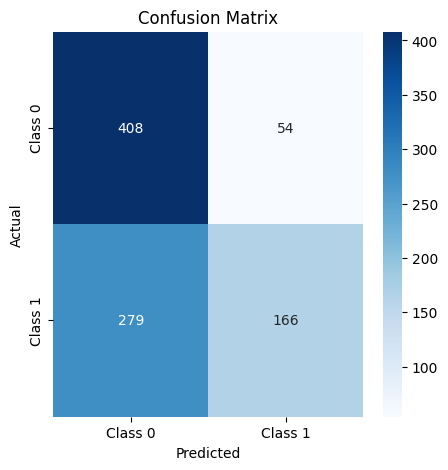

In [ ]:
# Define model
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(250, 250, 3))
base_model.trainable = False

global_avg_pool = GlobalAveragePooling2D()(base_model.output)
dropout = Dropout(0.5)(global_avg_pool)
output_layer = Dense(1, activation='sigmoid')(dropout)

model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_dataset, validation_data=test_dataset, epochs=15)

# Plot Loss and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Test Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Test Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()

# Evaluate Model
y_pred_prob = model.predict(test_dataset)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred))



In [ ]:
# Evaluate model
loss, accuracy = model.evaluate(test_dataset)
print(f'Resnet Accuracy: {accuracy * 100:.2f}%')

114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.6412 - loss: 0.6532
Resnet Accuracy: 63.29%


#EfficientNetB3

Epoch 1/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 113s 88ms/step - accuracy: 0.5081 - loss: 0.7083 - val_accuracy: 0.5072 - val_loss: 0.6931
Epoch 2/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.4929 - loss: 0.7063 - val_accuracy: 0.5072 - val_loss: 0.6929
Epoch 3/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.4927 - loss: 0.7024 - val_accuracy: 0.5226 - val_loss: 0.6927
Epoch 4/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5048 - loss: 0.7008 - val_accuracy: 0.5072 - val_loss: 0.6924
Epoch 5/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.5218 - loss: 0.6962 - val_accuracy: 0.4928 - val_loss: 0.6940
Epoch 6/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.4978 - loss: 0.7027 - val_accuracy: 0.4928 - val_loss: 0.6933
Epoch 7/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 35s 31ms/step - accuracy: 0.5023 - loss: 0.7015 - val_accuracy: 0.5292 - val_loss: 0.6921
Epoch 8/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.5092 - loss: 0.7005 -

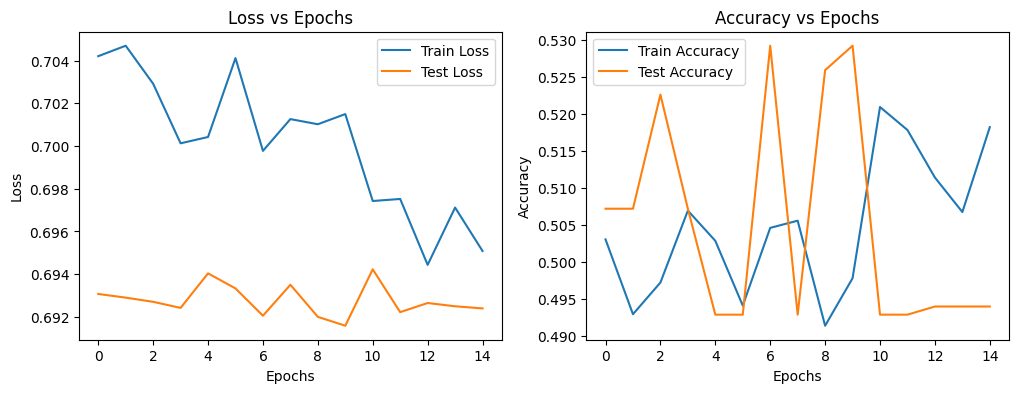

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split



# Define model
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(250, 250, 3))
base_model.trainable = False

global_avg_pool = GlobalAveragePooling2D()(base_model.output)
dropout = Dropout(0.5)(global_avg_pool)
output_layer = Dense(1, activation='sigmoid')(dropout)

model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_dataset, validation_data=test_dataset, epochs=15)

# Evaluate model
loss, accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Plot Loss and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Test Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Test Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()


#VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.5101 - loss: 0.8277 - val_accuracy: 0.5799 - val_loss: 0.6767
Epoch 2/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.5347 - loss: 0.7121 - val_accuracy: 0.6240 - val_loss: 0.6677
Epoch 3/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - accuracy: 0.5492 - loss: 0.6903 - val_accuracy: 0.6494 - val_loss: 0.6588
Epoch 4/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.5787 - loss: 0.6729 - val_accuracy: 0.6659 - val_loss: 0.6509
Epoch 5/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.6146 - loss: 0.6547 - val_accuracy: 0.6692 - val_loss: 0.6445
Epoch 6/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.6216 - loss: 0.6504 - val_accuracy: 0.6725 - val_loss: 0.6383
Epoch 7/15
643/643 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.6229 - loss: 0.6443 - val_accuracy: 0.6858 - val_loss: 0.6303
Epoch 8/15
643/643 ━━━━━━━━━━━━━━━━━━━━

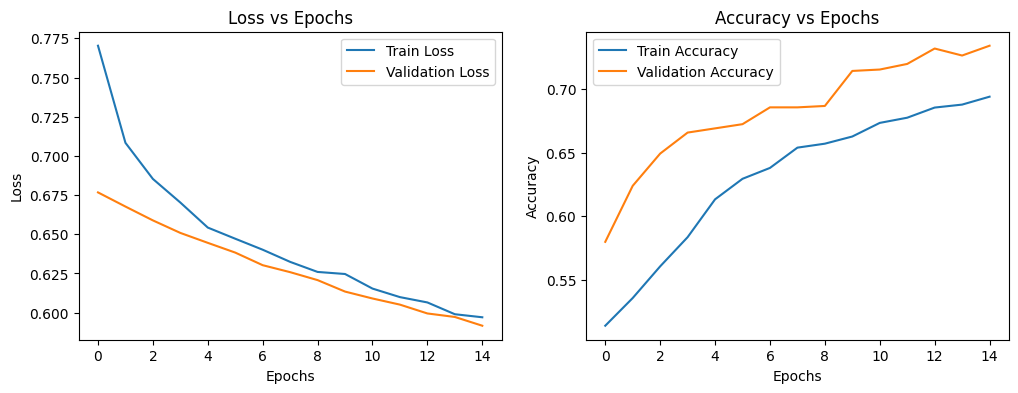

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split

# Define model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(250, 250, 3))
base_model.trainable = False

global_avg_pool = GlobalAveragePooling2D()(base_model.output)
dropout = Dropout(0.5)(global_avg_pool)
output_layer = Dense(1, activation='sigmoid')(dropout)

model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_dataset, validation_data=test_dataset, epochs=15)

# Evaluate model
loss, accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Plot Loss and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()


#DenseNet121

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
643/643 ━━━━━━━━━━━━━━━━━━━━ 111s 92ms/step - accuracy: 0.5991 - loss: 0.8594 - val_accuracy: 0.8313 - val_loss: 0.3829 - learning_rate: 1.0000e-04
Epoch 2/20
643/643 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.7601 - loss: 0.5509 - val_accuracy: 0.8776 - val_loss: 0.2824 - learning_rate: 1.0000e-04
Epoch 3/20
643/643 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.8169 - loss: 0.4269 - val_accuracy: 0.9074 - val_loss: 0.2162 - learning_rate: 1.0000e-04
Epoch 4/20
643/643 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.8554 - loss: 0.3562 - val_accuracy: 0.9239 - val_loss: 0.1784 - learning_rate: 1.0000e-04
Epoch 5/20
643/643 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.8975 - loss: 0.2451 - val_accuracy: 0.9449 - val_loss: 0.1543 - learning_rate: 1.0000e-04
Epoch 6/20
643/643 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.9095 - loss: 0.2307 - val_accuracy: 0.9537 - val_loss: 0.1132 - learning_rate: 1.0000e-04


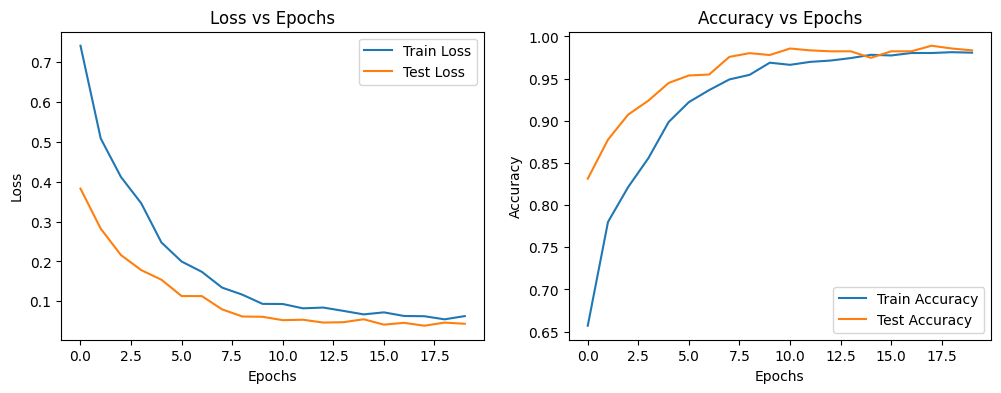

114/114 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       447
           1       0.99      0.99      0.99       460

    accuracy                           0.99       907
   macro avg       0.99      0.99      0.99       907
weighted avg       0.99      0.99      0.99       907



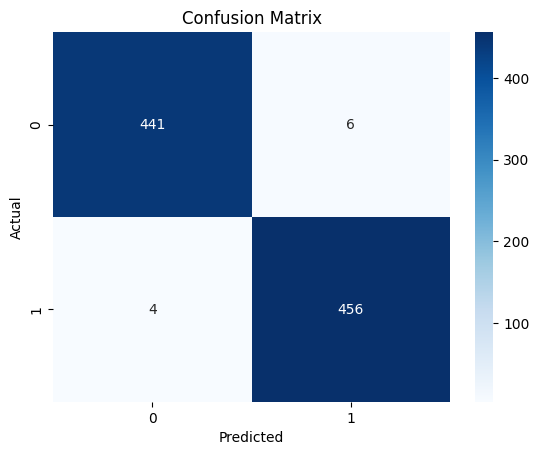

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split

# Define model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(250, 250, 3))
for layer in base_model.layers[:-10]:  # Fine-tuning last 10 layers
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output_layer = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

# Train model
history = model.fit(train_dataset, validation_data=test_dataset, epochs=20, callbacks=[early_stopping, lr_scheduler])

# Plot Loss and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Test Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Test Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()

# Evaluate model
y_pred = (model.predict(test_dataset) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))



In [ ]:
# Evaluate model
loss, accuracy = model.evaluate(test_dataset)
print(f'DenseNet121 Accuracy: {accuracy * 100:.2f}%')


114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9891 - loss: 0.0365
DenseNet121 Accuracy: 98.90%


#PREDICTION

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


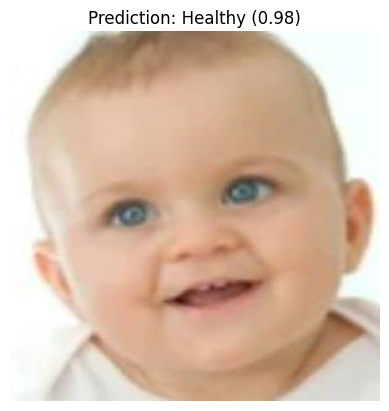

('Healthy', 0.9772357009351254)

In [ ]:
import os
# Mount Google Drive
drive.mount('/content/drive')

# List files in the directory
dir_path = "/content/drive/MyDrive/dataset/Down syndromedataset/test/"


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def preprocess_single_image(image_path):
    """Preprocess a single image for model prediction."""
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (250, 250))
    img = img / 255.0  # Normalize pixel values
    img = tf.expand_dims(img, axis=0)  # Add batch dimension
    return img

def predict_image(image_path, model):
    """Predict if an image is Healthy or Down Syndrome."""
    img = preprocess_single_image(image_path)
    prediction = model.predict(img)[0][0]

    class_label = "Healthy" if prediction < 0.5 else "Down Syndrome"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # Show image
    plt.imshow(tf.io.decode_jpeg(tf.io.read_file(image_path)))
    plt.axis("off")
    plt.title(f"Prediction: {class_label} ({confidence:.2f})")
    plt.show()

    return class_label, confidence

# Example usage
image_path = "/content/drive/MyDrive/dataset/Down syndromedataset/test/healty_1205_jpg.rf.0bd3a3a12edfd7d7392c0a666e818026.jpg"
predict_image(image_path, model)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


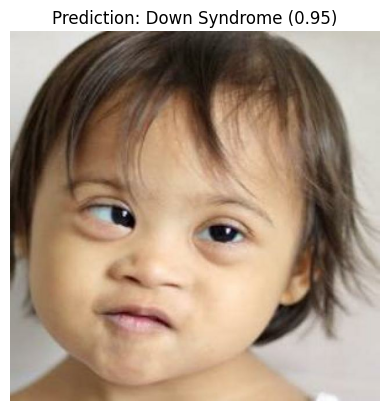

('Down Syndrome', 0.9520919)

In [ ]:
import os
# Mount Google Drive
drive.mount('/content/drive')

# List files in the directory
dir_path = "/content/drive/MyDrive/dataset/Down syndromedataset/test/"


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def preprocess_single_image(image_path):
    """Preprocess a single image for model prediction."""
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (250, 250))
    img = img / 255.0  # Normalize pixel values
    img = tf.expand_dims(img, axis=0)  # Add batch dimension
    return img

def predict_image(image_path, model):
    """Predict if an image is Healthy or Down Syndrome."""
    img = preprocess_single_image(image_path)
    prediction = model.predict(img)[0][0]

    class_label = "Healthy" if prediction < 0.5 else "Down Syndrome"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # Show image
    plt.imshow(tf.io.decode_jpeg(tf.io.read_file(image_path)))
    plt.axis("off")
    plt.title(f"Prediction: {class_label} ({confidence:.2f})")
    plt.show()

    return class_label, confidence

# Example usage
image_path = "/content/drive/MyDrive/dataset/Down syndromedataset/test/down_1511_jpg.rf.518904cebb2caf35a0670bf5214ef2bd.jpg"
predict_image(image_path, model)


In [ ]:
!pip install gradio

import gradio as gr
import random

def predict_image(image):
    prediction = random.choice(['healthy', 'down'])
    return prediction

iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Down Syndrome Prediction",
    description="Upload an image to predict if the person has Down Syndrome or not."
)

iface.launch()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.1 MB/s eta 0:00:00
It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b865ca905cccaf23ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory